## Projeto de ML para previsao de vendas baseeado num CRM

In [49]:
#Importação de bibliotecas necessárias
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as pl

# pipelines e transformadores 
from sklearn.pipeline import Pipeline
from sklearn.base import TransformerMixin, BaseEstimator
from sklearn.compose import ColumnTransformer

# codificação de variaveis
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.feature_extraction.text import CountVectorizer

# normalização
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler

# dados faltantes
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import KNNImputer, SimpleImputer, IterativeImputer

# modelagem para classificação
from sklearn.linear_model import LogisticRegression # O clássico para probabilidade/score
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.ensemble import GradientBoostingClassifier
from catboost import CatBoostClassifier


In [50]:
# Unir o dataset 
# Carregar todas as tabelas separadas
df_pipeline = pd.read_csv('dataset/sales_pipeline.csv') 
df_accounts = pd.read_csv('dataset/accounts.csv')
df_products = pd.read_csv('dataset/products.csv')
df_teams    = pd.read_csv('dataset/sales_teams.csv')

# Fazer o cruzamento
# Trazendo os dados para dentro do pipeline
df_master = pd.merge(df_pipeline, df_accounts, on="account", how="left")
df_master = pd.merge(df_master, df_products, on="product", how="left")
df_master = pd.merge(df_master, df_teams, on="sales_agent", how="left")

# Conferir o resultado
print("Tamanho da base final:", df_master.shape)
print(df_master.head())

Tamanho da base final: (8800, 18)
  opportunity_id      sales_agent         product  account deal_stage  \
0       1C1I7A6R      Moses Frase  GTX Plus Basic  Cancity        Won   
1       Z063OYW0  Darcel Schlecht          GTXPro    Isdom        Won   
2       EC4QE1BX  Darcel Schlecht      MG Special  Cancity        Won   
3       MV1LWRNH      Moses Frase       GTX Basic  Codehow        Won   
4       PE84CX4O        Zane Levy       GTX Basic   Hatfan        Won   

  engage_date  close_date  close_value    sector  year_established  revenue  \
0  2016-10-20  2017-03-01       1054.0    retail            2001.0   718.62   
1  2016-10-25  2017-03-11       4514.0   medical            2002.0  3178.24   
2  2016-10-25  2017-03-07         50.0    retail            2001.0   718.62   
3  2016-10-25  2017-03-09        588.0  software            1998.0  2714.90   
4  2016-10-25  2017-03-02        517.0  services            1982.0   792.46   

   employees office_location     subsidiary_of serie

In [51]:
# preparação dos dados
# Filtrar apenas oportunidades fechadas para treinar o modelo
df_treino = df_master[df_master['deal_stage'].isin(['Won','Lost'])].copy()

# Converter datas para o formato correto
df_treino['engage_date'] = pd.to_datetime(df_treino['engage_date'])
df_treino['close_date'] = pd.to_datetime(df_treino['close_date'])

# criando coluna de tempo de ciclo de venda (em dias)
df_treino['cycle_time'] = (df_treino['close_date'] - df_treino['engage_date']).dt.days

# Criar a coluna 'Target' (1 para Won, 0 para Lost)
df_treino['Target'] = df_treino['deal_stage'].apply(lambda x: 1 if x == 'Won' else 0)

# Selecionar as colunas que o modelo vai usar para aprender (Features)
colunas_para_usar = [
    'sales_agent',   # Categórica
    'product',       # Categórica
    'sector',        # Categórica
    'revenue',       # NUMÉRICA (Faturamento da conta)
    'employees',     # NUMÉRICA (Nº de funcionários)
    'cycle_time',    # NUMÉRICA (Dias que levou para fechar)
    'Target'         # O nosso alvo
]

# limpar dados vazios
df_modelo = df_treino[colunas_para_usar].dropna()

# Transformar texto em números (One-Hot Encoding)
df_modelo_numerico = pd.get_dummies(df_modelo, drop_first=True)

print("Formato dos dados prontos para o modelo:", df_modelo_numerico.shape)
print(df_modelo_numerico.head())

Formato dos dados prontos para o modelo: (6711, 48)
   revenue  employees  cycle_time  Target  sales_agent_Boris Faz  \
0   718.62     2448.0         132       1                  False   
1  3178.24     4540.0         137       1                  False   
2   718.62     2448.0         133       1                  False   
3  2714.90     2641.0         135       1                  False   
4   792.46     1299.0         128       1                  False   

   sales_agent_Cassey Cress  sales_agent_Cecily Lampkin  \
0                     False                       False   
1                     False                       False   
2                     False                       False   
3                     False                       False   
4                     False                       False   

   sales_agent_Corliss Cosme  sales_agent_Daniell Hammack  \
0                      False                        False   
1                      False                        False   
2

In [52]:
# definir quem é x e y
X = df_modelo_numerico.drop('Target', axis=1) # todas as colunas exceto o alvo
y = df_modelo_numerico['Target']

# definir quem o modelo vai estudar 
X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size = 0.2, random_state = 42)

# treinar IA e testar
modelo_rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
modelo_rf.fit(X_treino, y_treino)

# A grande jogada do Comercial: Extrair o Score de Risco!
# O predict_proba retorna duas probabilidades [chance de Perder(0), chance de Ganhar(1)]
probabilidades_rf = modelo_rf.predict_proba(X_teste)

# Queremos o Score de RISCO, ou seja, a chance de PERDER (índice 0) x 100
score_risco = probabilidades_rf[:, 0] * 100

previsoes_rf = modelo_rf.predict(X_teste)

# Criar uma tabela final para visualizar o resultado e exportar
resultado_final = X_teste.copy()
resultado_final['Status_Real_Gabarito'] = y_teste.map({1: 'Ganho', 0: 'Perdido'})
resultado_final['Score_Risco_Calculado'] = score_risco.round(0).astype(int)

# taxa de acerto
acuracia_rf = accuracy_score(y_teste, previsoes_rf) * 100

# Mostrar uma amostra dos resultados
print("\n--- AMOSTRA: SCORE DE RISCO GERADO PELO MODELO ---")
print(resultado_final[['Status_Real_Gabarito', 'Score_Risco_Calculado']].sample(15, random_state=1))



--- AMOSTRA: SCORE DE RISCO GERADO PELO MODELO ---
     Status_Real_Gabarito  Score_Risco_Calculado
7406                Ganho                     53
3300                Ganho                     16
1256              Perdido                     20
7329              Perdido                     12
6915                Ganho                     51
519                 Ganho                     40
5703                Ganho                     40
6782              Perdido                     29
4250              Perdido                     20
767                 Ganho                     16
393                 Ganho                      9
2635                Ganho                     70
7836              Perdido                     58
6056              Perdido                     20
2797                Ganho                     28


In [63]:
# Lista das colunas numéricas que adicionamos
colunas_numericas = ['revenue', 'employees', 'cycle_time']

#tratamento de outliers
df_modelo['revenue'] = np.log1p(df_modelo['revenue'])
df_modelo['employees'] = np.log1p(df_modelo['employees'])

# Criar o escalonador
scaler = StandardScaler()

# Ajustar e transformar apenas as colunas numéricas no X_treino e X_teste
X_treino[colunas_numericas] = scaler.fit_transform(X_treino[colunas_numericas])
X_teste[colunas_numericas] = scaler.transform(X_teste[colunas_numericas])

print("Dados normalizados com sucesso!")

Dados normalizados com sucesso!


In [54]:
# criar mais modelos para comparar depois
modelo_lr = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')

# treinar o modelo 
print("Treinando a Regressão Logística...")
modelo_lr.fit(X_treino, y_treino)

# testar as previsões 
previsoes_lr = modelo_lr.predict(X_teste)
acuracia_lr = accuracy_score(y_teste, previsoes_lr) * 100
print(f"Taxa de Acerto (Regressão Logística): {acuracia_lr:.2f}%\n")

# probabilidades
probabilidades_lr = modelo_lr.predict_proba(X_teste)
score_risco_lr = probabilidades_lr[:, 0] * 100

# Visualizar o resultado prático
resultado_lr = X_teste.copy()
resultado_lr['Status_Real'] = y_teste.map({1: 'Ganho', 0: 'Perdido'})
resultado_lr['Score_Risco_Logistica'] = score_risco_lr.round(0).astype(int)

print("--- AMOSTRA: SCORE DE RISCO (REGRESSÃO LOGÍSTICA) ---")
print(resultado_lr[['Status_Real', 'Score_Risco_Logistica']].sample(15, random_state=1))

Treinando a Regressão Logística...
Taxa de Acerto (Regressão Logística): 53.61%

--- AMOSTRA: SCORE DE RISCO (REGRESSÃO LOGÍSTICA) ---
     Status_Real  Score_Risco_Logistica
7406       Ganho                     61
3300       Ganho                     35
1256     Perdido                     43
7329     Perdido                     48
6915       Ganho                     53
519        Ganho                     52
5703       Ganho                     38
6782     Perdido                     41
4250     Perdido                     61
767        Ganho                     44
393        Ganho                     41
2635       Ganho                     58
7836     Perdido                     61
6056     Perdido                     48
2797       Ganho                     52


In [55]:
# Criar e Treinar a Árvore de Decisão
print("Treinando a Árvore de Decisão (A Árvore Única)...")
modelo_dt = DecisionTreeClassifier(random_state=42)
modelo_dt.fit(X_treino, y_treino)

# Calcular a Taxa de Acerto (Acurácia)
# Usamos .predict() para ter 0 ou 1
previsoes_dt = modelo_dt.predict(X_teste)
acuracia_dt = accuracy_score(y_teste, previsoes_dt) * 100

# Gerar o Score de Risco (Probabilidades)
# Usamos .predict_proba() para ter a %
probabilidades_dt = modelo_dt.predict_proba(X_teste)
score_risco_dt = probabilidades_dt[:, 0] * 100

# Ver a Amostra de Scores
resultado_dt = X_teste.copy()
resultado_dt['Status_Real'] = y_teste.map({1: 'Ganho', 0: 'Perdido'})
resultado_dt['Score_Risco_Arvore'] = score_risco_dt.round(0).astype(int)

print("\n--- AMOSTRA: SCORE DE RISCO (DECISION TREE) ---")
print(resultado_dt[['Status_Real', 'Score_Risco_Arvore']].sample(10, random_state=1))

# 4. Exibir o Placar Comparativo Entre Modelos
print("\n--- 🏆 PLACAR DE ACURÁCIA ATUALIZADO ---")
print(f"Regressão Logística:        {acuracia_lr:.2f}%")
print(f"Random Forest:        {acuracia_rf:.2f}%")
print(f"Árvore de Decisão:    {acuracia_dt:.2f}%")

Treinando a Árvore de Decisão (A Árvore Única)...

--- AMOSTRA: SCORE DE RISCO (DECISION TREE) ---
     Status_Real  Score_Risco_Arvore
7406       Ganho                   0
3300       Ganho                   0
1256     Perdido                   0
7329     Perdido                   0
6915       Ganho                   0
519        Ganho                 100
5703       Ganho                   0
6782     Perdido                   0
4250     Perdido                   0
767        Ganho                   0

--- 🏆 PLACAR DE ACURÁCIA ATUALIZADO ---
Regressão Logística:        53.61%
Random Forest:        58.90%
Árvore de Decisão:    53.54%


In [56]:
# Criar e Treinar o Gradient Boosting (O "corretor de erros")
print("Treinando o Gradient Boosting...")
modelo_gb = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
modelo_gb.fit(X_treino, y_treino)

# Calcular a taxa de acerto 
previsoes_gb = modelo_gb.predict(X_teste)
acuracia_gb = accuracy_score(y_teste, previsoes_gb) * 100

# probabilidades
probabilidades_gb = modelo_gb.predict_proba(X_teste)
score_risco_gb = probabilidades_gb[:, 0] * 100

# Visualizar Amostra dos Resultados
resultado_gb = X_teste.copy()
resultado_gb['Status_Real'] = y_teste.map({1: 'Ganho', 0: 'Perdido'})
resultado_gb['Score_Risco_GB'] = score_risco_gb.round(0).astype(int)

print("\n--- AMOSTRA: SCORE DE RISCO (GRADIENT BOOSTING) ---")
print(resultado_gb[['Status_Real', 'Score_Risco_GB']].sample(10, random_state=1))

# PLACAR FINAL ATUALIZADO
print("\n--- 🏆 PLACAR DE ACURÁCIA FINAL ---")
print(f"Regressão Logística:  {acuracia_lr:.2f}%") 
print(f"Gradient Boosting:    {acuracia_gb:.2f}%")
print(f"Random Forest:        {acuracia_rf:.2f}%")
print(f"Árvore de Decisão:    {acuracia_dt:.2f}%")

Treinando o Gradient Boosting...

--- AMOSTRA: SCORE DE RISCO (GRADIENT BOOSTING) ---
     Status_Real  Score_Risco_GB
7406       Ganho              42
3300       Ganho              21
1256     Perdido              33
7329     Perdido              33
6915       Ganho              41
519        Ganho              29
5703       Ganho              28
6782     Perdido              26
4250     Perdido              38
767        Ganho              33

--- 🏆 PLACAR DE ACURÁCIA FINAL ---
Regressão Logística:  53.61%
Gradient Boosting:    63.22%
Random Forest:        58.90%
Árvore de Decisão:    53.54%



--- 🔍 QUAIS FATORES MAIS AFETAM O RISCO? (Top 10) ---
                        Variável  Importância
2                     cycle_time     0.433629
0                        revenue     0.094845
1                      employees     0.089591
36           product_MG Advanced     0.038163
18   sales_agent_Lajuana Vencill     0.025443
10      sales_agent_Elease Gluck     0.021689
9      sales_agent_Donn Cantrell     0.017495
35                product_GTXPro     0.017283
12  sales_agent_Gladys Colclough     0.017175
39                sector_finance     0.016212


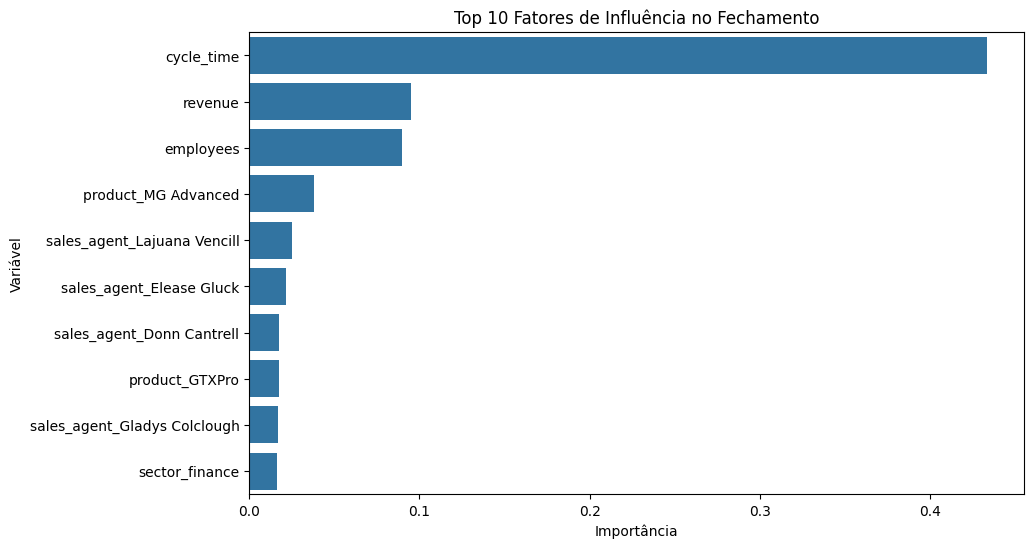

In [57]:
# Pegar as importâncias do modelo
importancias = modelo_gb.feature_importances_
colunas = X_treino.columns

# Criar um DataFrame para facilitar a visualização
df_importancia = pd.DataFrame({'Variável': colunas, 'Importância': importancias})
df_importancia = df_importancia.sort_values(by='Importância', ascending=False)

# Mostrar o Top 10 fatores que mais influenciam o Score
print("\n--- 🔍 QUAIS FATORES MAIS AFETAM O RISCO? (Top 10) ---")
print(df_importancia.head(10))

# Gerar um gráfico para o seu relatório
pl.figure(figsize=(10, 6))
sns.barplot(x='Importância', y='Variável', data=df_importancia.head(10))
pl.title('Top 10 Fatores de Influência no Fechamento')
pl.show()

## Interpretando os Insights para o Dashboard:
- O Produto é Rei (`product_GTX Basic`): Com 7.6% de importância, este é o fator isolado que mais define o destino de um negócio. **A escolha do produto é o fator número 1 na previsibilidade de risco**.

- Tecnologia e Entretenimento são os setores "chave": Os setores technolgy, entertainment e software aparecem logo no topo. Isso significa que o modelo aprendeu que, dependendo do setor do lead, a chance de fechar muda drasticamente.

- Vendedores de Impacto: Apenas dois vendedores aparecem no Top 10: Hayden Neloms e Donn Cantrell. Isso é um insight valioso! Significa que a atuação desses dois especificamente é um padrão forte (seja para ganhar muito ou perder muito).

In [58]:
#usando ROC_AUC_SCORE
#O ROC-AUC mede o quanto o seu modelo consegue separar as classes. 
#Um score de 0.5 significa que ele está chutando; acima de 0.7 já é um modelo promissor.
prob_ganhar = modelo_gb.predict_proba(X_teste)[:, 1]

#calcular o roc_auc
auc_score = roc_auc_score(y_teste, prob_ganhar)
print(f"ROC-AUC Score: {auc_score:.4f}")

ROC-AUC Score: 0.5795


In [59]:
modelo_cat = CatBoostClassifier(iterations=100, learning_rate=0.1, depth=6, verbose=False)
modelo_cat.fit(X_treino, y_treino)

# Testando o ROC-AUC dele
prob_cat = modelo_cat.predict_proba(X_teste)[:, 1]
print(f"ROC-AUC CatBoost: {roc_auc_score(y_teste, prob_cat):.4f}")

ROC-AUC CatBoost: 0.5778


In [60]:
# rodando novamente baseado em dias
df_treino['cycle_time'] = (pd.to_datetime(df_treino['close_date']) - pd.to_datetime(df_treino['engage_date'])).dt.days

auc = roc_auc_score(y_teste, modelo_gb.predict_proba(X_teste)[:, 1])
print(f"Novo ROC-AUC: {auc:.4f}")

Novo ROC-AUC: 0.5795


In [64]:
# criando novo modelo com parametros para melhorar o roc_auc e transformar em um modelo confiavel
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import roc_auc_score

# definir o modelo que desafiará os anteriores
modelo_gb_top = GradientBoostingClassifier(random_state=42)

# definir os pareametros (aqui ao inves do modelo aprender os nomes dos vendedores ele aprenderá quanto de conversão o vendedor tem)
parametros = {
    'n_estimators' : [100, 200, 300],
    'learning_rate' : [0.01, 0.05, 0.1],
    'max_depth': [3, 4, 5, 6],
    'subsample': [0.7, 0.8, 0.9]
}
# busca automatica - gerar 10 combinações aleatorias
print("Iniciando busca pelos melhores parâmetros (isso pode levar 1 min)...")
random_search = RandomizedSearchCV(modelo_gb_top, parametros, n_iter=10, 
                                   scoring='roc_auc', cv=5, verbose=1, random_state=42)
random_search.fit(X_treino, y_treino)

# avaliando o melhor modelo encontrado
melhor_modelo = random_search.best_estimator_
probabilidades = melhor_modelo.predict_proba(X_teste)[:, 1]
novo_auc = roc_auc_score(y_teste, probabilidades)

print(f"\n✅ Melhor ROC-AUC encontrado: {novo_auc:.4f}")
print(f"Melhores parâmetros: {random_search.best_params_}")


Iniciando busca pelos melhores parâmetros (isso pode levar 1 min)...
Fitting 5 folds for each of 10 candidates, totalling 50 fits

✅ Melhor ROC-AUC encontrado: 0.5857
Melhores parâmetros: {'subsample': 0.8, 'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.01}
